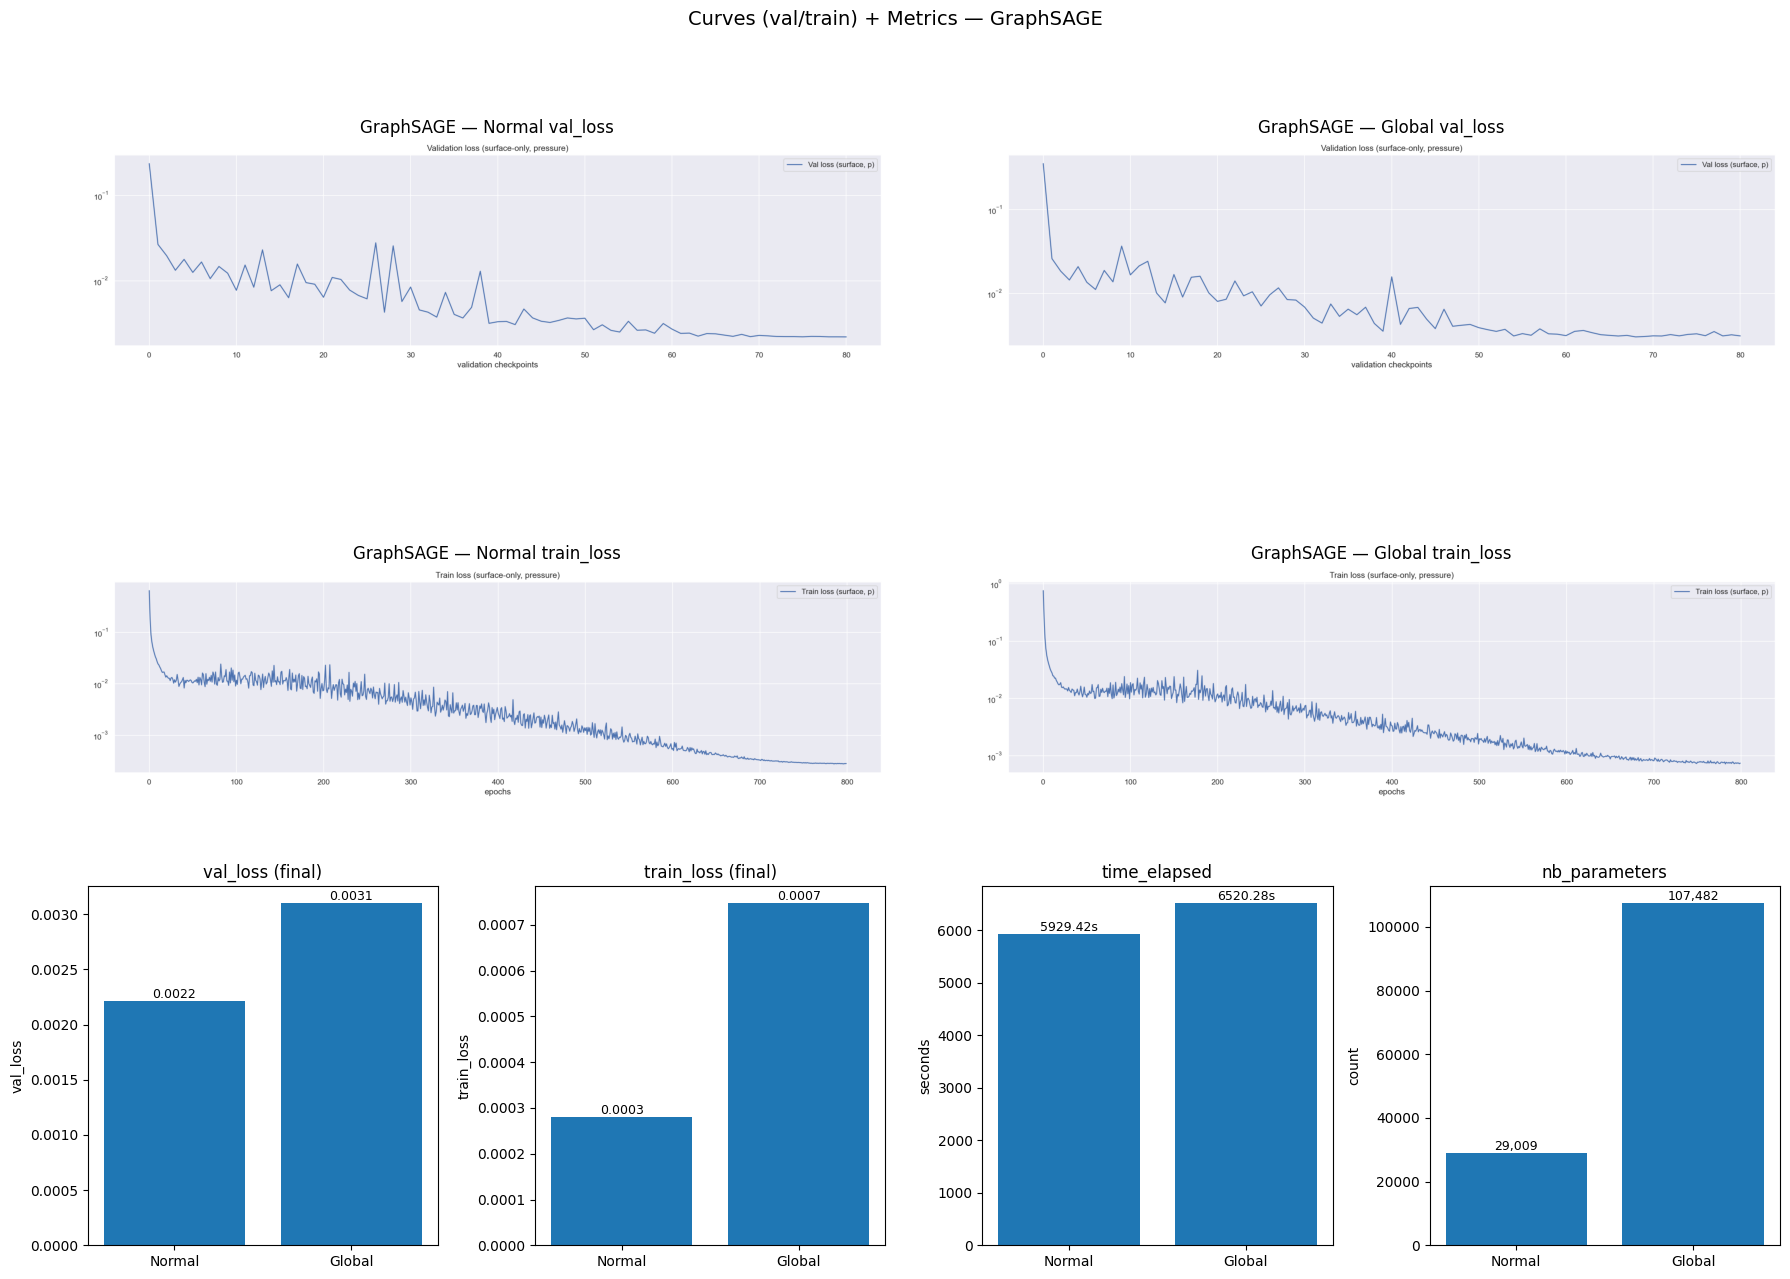

Saved -> comparisons\GraphSAGE_curves_train_val_metrics.png


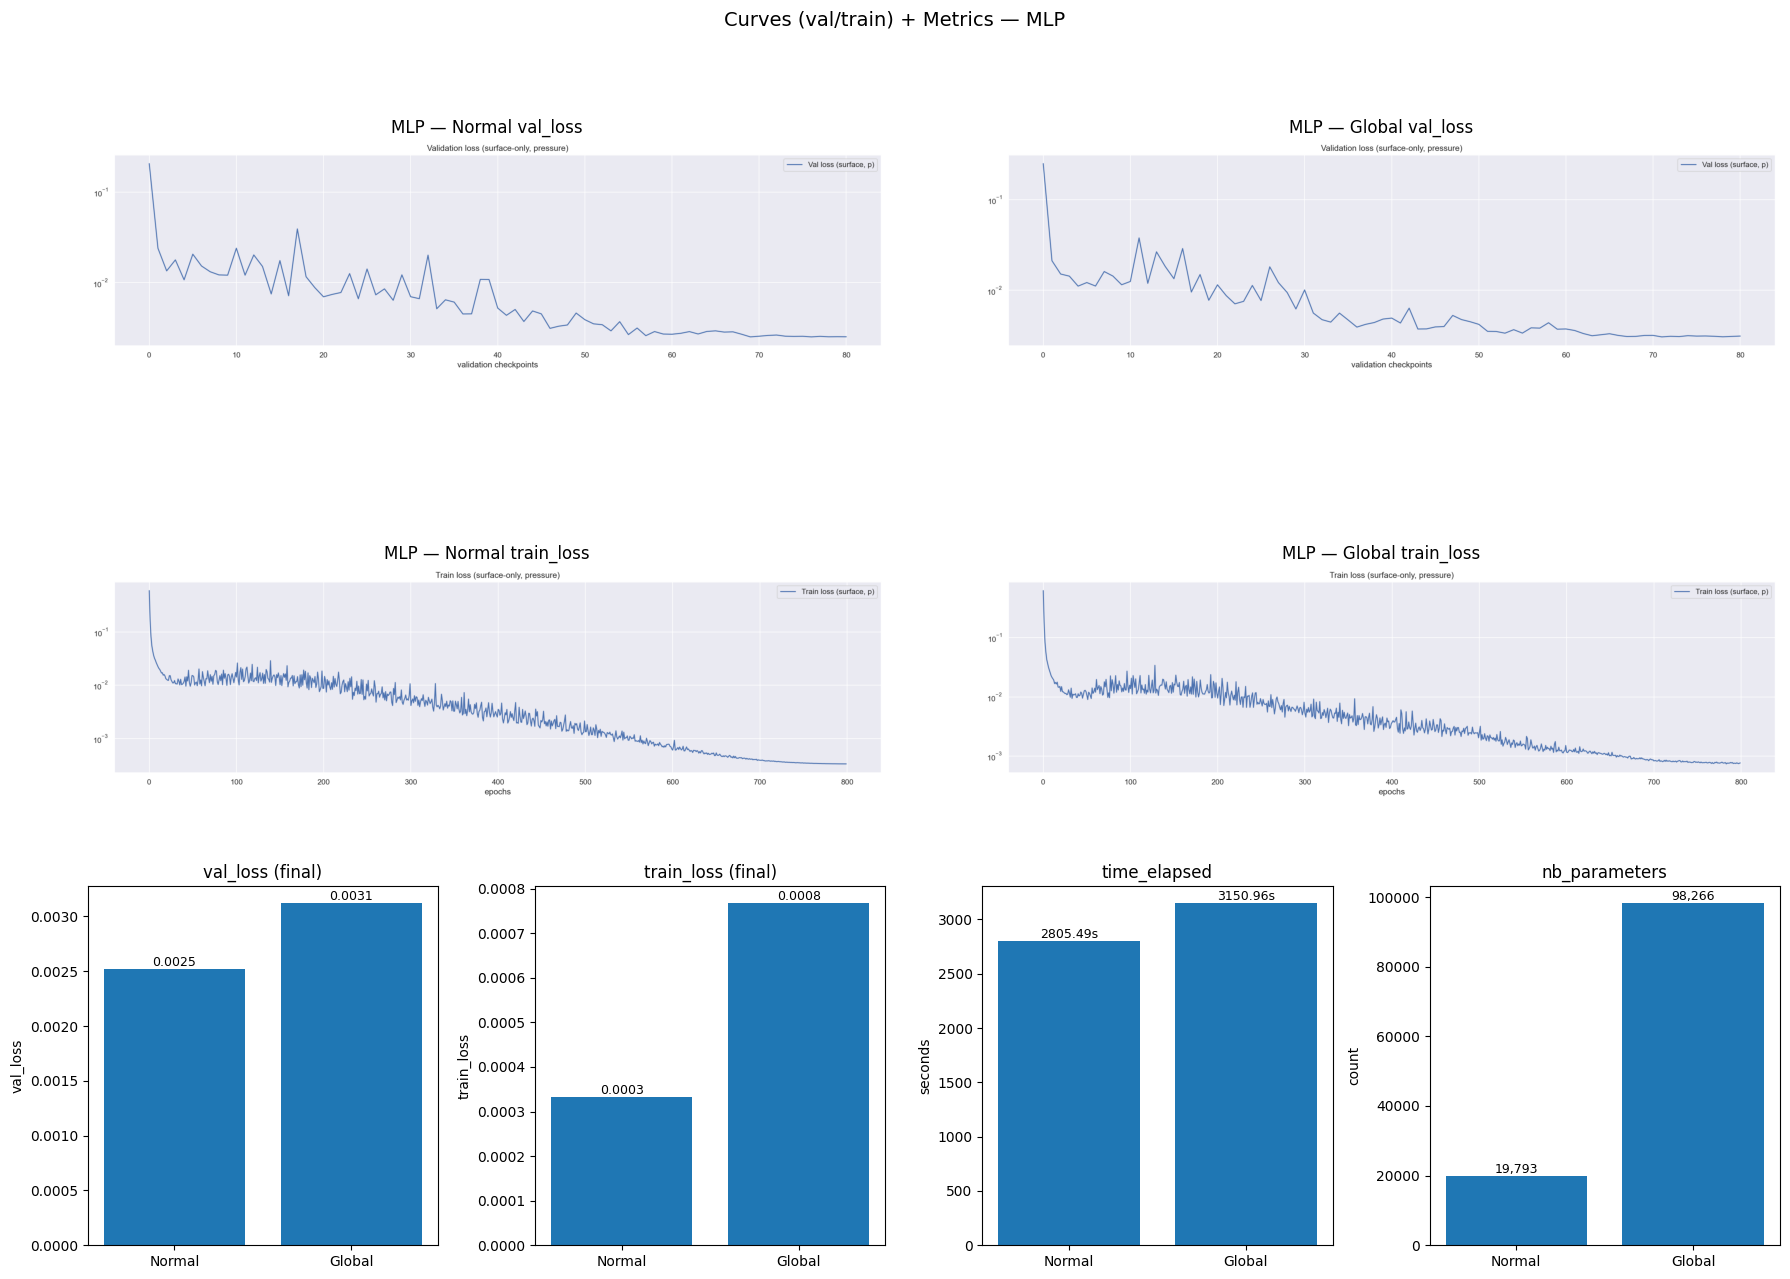

Saved -> comparisons\MLP_curves_train_val_metrics.png


In [1]:
# --- Full comparison: val/train curves + scalar metrics (Jupyter-friendly) ---
from pathlib import Path
import json, math
import matplotlib.pyplot as plt
from PIL import Image

# Show plots inline
%matplotlib inline

# ---------- Config ----------
SEARCH_ROOT = Path(".")
OUT_DIR = Path("comparisons")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ---------- Helpers ----------
def infer_variant_and_base(stem: str):
    name = stem.replace("_log", "")
    return (name[:-6], "Global") if name.endswith("Global") else (name, "Normal")

def _fmt(v, kind="float"):
    if v is None or (isinstance(v, float) and (math.isnan(v) or math.isinf(v))):
        return "N/A"
    if kind == "int":  return f"{int(v):,}"
    if kind == "time": return f"{float(v):.2f}s"
    return f"{float(v):.4f}"

def _num(v):
    try:
        f = float(v)
        return None if math.isnan(f) or math.isinf(f) else f
    except Exception:
        return None

def _bar(ax, labels, values, title, ylabel, fmt_kind="float"):
    heights = [(_num(v) if _num(v) is not None else 0.0) for v in values]
    ax.bar(labels, heights)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    for i, v in enumerate(values):
        ax.text(i, heights[i], _fmt(v, fmt_kind), ha="center", va="bottom", fontsize=9)

# ---------- Main ----------
def make_curve_plus_bar_panels():
    entries = {}
    for f in SEARCH_ROOT.rglob("*_log.json"):
        data = json.loads(f.read_text(encoding="utf-8", errors="ignore"))
        base, variant = infer_variant_and_base(f.stem)
        entries.setdefault(base, {})[variant] = {
            "log": f,
            "val":  data.get("val_loss"),
            "train": data.get("train_loss"),
            "time": data.get("time_elapsed"),
            "params": data.get("nb_parameters"),
        }

    for model, pair in sorted(entries.items()):
        if "Normal" not in pair or "Global" not in pair:
            continue

        n, g = pair["Normal"], pair["Global"]
        normal_dir, global_dir = n["log"].parent, g["log"].parent

        # Curves (assumed to exist)
        img_nv = Image.open(normal_dir / "val_loss.png")
        img_gv = Image.open(global_dir / "val_loss.png")
        img_nt = Image.open(normal_dir / "train_loss.png")
        img_gt = Image.open(global_dir / "train_loss.png")

        # Scalars
        val_n, val_g = n["val"], g["val"]
        tr_n,  tr_g  = n["train"], g["train"]
        t_n,   t_g   = n["time"], g["time"]
        p_n,   p_g   = n["params"], g["params"]

        # --- Figure layout ---
        fig = plt.figure(figsize=(18, 13))
        gs = fig.add_gridspec(3, 4, height_ratios=[2.5, 2.5, 2])

        # Row 1: val_loss.png (Normal | Global)
        ax_nv = fig.add_subplot(gs[0, 0:2])
        ax_gv = fig.add_subplot(gs[0, 2:4])
        # Row 2: train_loss.png (Normal | Global)
        ax_nt = fig.add_subplot(gs[1, 0:2])
        ax_gt = fig.add_subplot(gs[1, 2:4])
        # Row 3: 4 metrics bars
        ax_val  = fig.add_subplot(gs[2, 0])
        ax_tr   = fig.add_subplot(gs[2, 1])
        ax_time = fig.add_subplot(gs[2, 2])
        ax_parm = fig.add_subplot(gs[2, 3])

        # --- Curves ---
        for ax, img, title in [
            (ax_nv, img_nv, f"{model} — Normal val_loss"),
            (ax_gv, img_gv, f"{model} — Global val_loss"),
            (ax_nt, img_nt, f"{model} — Normal train_loss"),
            (ax_gt, img_gt, f"{model} — Global train_loss"),
        ]:
            ax.imshow(img); ax.axis("off"); ax.set_title(title)

        # --- Bars ---
        labels = ["Normal", "Global"]
        _bar(ax_val,  labels, [val_n, val_g],  "val_loss (final)",   "val_loss", fmt_kind="float")
        _bar(ax_tr,   labels, [tr_n,  tr_g],   "train_loss (final)", "train_loss", fmt_kind="float")
        _bar(ax_time, labels, [t_n,   t_g],    "time_elapsed",       "seconds",   fmt_kind="time")
        _bar(ax_parm, labels, [p_n,   p_g],    "nb_parameters",      "count",     fmt_kind="int")

        fig.suptitle(f"Curves (val/train) + Metrics — {model}", fontsize=14)
        fig.tight_layout()

        out = OUT_DIR / f"{model}_curves_train_val_metrics.png"
        fig.savefig(out, dpi=150, bbox_inches="tight")

        # Display inline in notebook
        plt.show()
        print(f"Saved -> {out}")

make_curve_plus_bar_panels()
